# Week 2 - Deliverables

In [2]:
import pandas as pd
from pathlib import Path

# Folder where the CSV files are stored
folder = Path(r"C:\Users\luoxu\OneDrive - University of Illinois - Urbana\idx-exchange\idx-summer-2026\california")

# Months you want: June 2025 to June 2026
months = [
    "202506", "202507", "202508", "202509", "202510", "202511", "202512",
    "202601", "202602", "202603", "202604", "202605", "202606"
]

dfs = []

for month in months:
    file_path = folder / f"CRMLSSold{month}.csv"
    
    df = pd.read_csv(file_path, low_memory=False)
    df["source_month"] = month  # optional, helps you know which file each row came from
    
    dfs.append(df)

# Combine all monthly files
big_df = pd.concat(dfs, ignore_index=True)

output_folder = Path(r"C:\Users\luoxu\OneDrive - University of Illinois - Urbana\idx-exchange\idx-summer-2026\output_csv")

# Save as one big CSV
output_path = output_folder / "CRMLSSold_202506_to_202606_combined.csv"
big_df.to_csv(output_path, index=False)

print("Combined file saved to:", output_path)

Combined file saved to: C:\Users\luoxu\OneDrive - University of Illinois - Urbana\idx-exchange\idx-summer-2026\output_csv\CRMLSSold_202506_to_202606_combined.csv


In [3]:
residential_df = big_df[
    (big_df['PropertyType'] == 'Residential') &
    (big_df['PropertySubType'] == 'SingleFamilyResidence')
]

In [4]:
residential_df.to_csv(output_folder / "residential.csv", index=False)

In [5]:
residential_df["ClosePrice"]

3          890000.0
10        1876384.0
11        4820000.0
13         865000.0
14         875000.0
            ...    
283141      40000.0
283142     865000.0
283143     280000.0
283169     595000.0
283173    3000000.0
Name: ClosePrice, Length: 143078, dtype: float64

In [6]:
residential_df.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [7]:
cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'LotSizeArea', 'LotSizeAcres', 'MainLevelBedrooms' ]


In [8]:
residential_df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ClosePrice,143078.0,1.342062e+06,7.893845e+06,0.0,625000.00,895000.0000,1425000.00,9.895000e+08
LivingArea,143004.0,2.051895e+03,1.049594e+03,0.0,1388.00,1823.0000,2444.00,5.650000e+04
BedroomsTotal,143078.0,3.496338e+00,9.625877e-01,0.0,3.00,3.0000,4.00,2.200000e+01
BathroomsTotalInteger,143066.0,2.636664e+00,1.130120e+00,0.0,2.00,2.0000,3.00,3.500000e+01
LotSizeSquareFeet,140629.0,3.756355e+05,1.751203e+07,0.0,5663.00,7285.0000,10454.00,1.938943e+09
LotSizeArea,140642.0,2.098009e+04,1.128845e+06,0.0,5403.00,7095.0000,9995.00,4.187423e+08
LotSizeAcres,140628.0,1.408705e+01,7.836060e+02,0.0,0.13,0.1673,0.24,1.276310e+05
MainLevelBedrooms,86970.0,2.265229e+00,1.456901e+00,0.0,1.00,3.0000,3.00,4.400000e+01


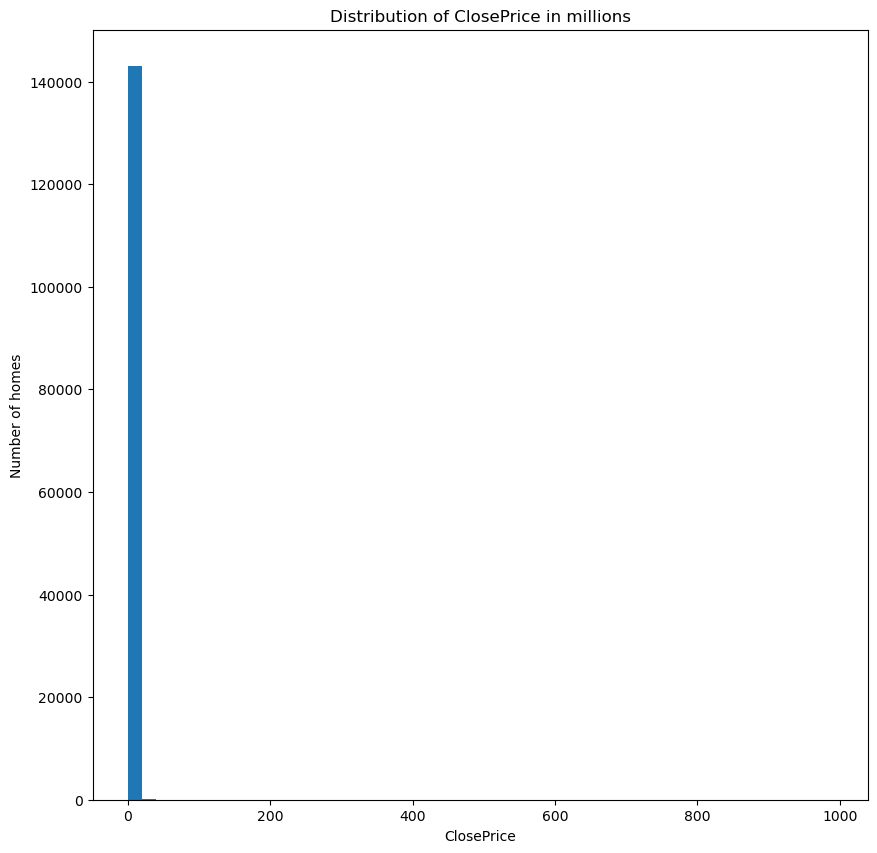

In [9]:
import matplotlib.pyplot as plt
import numpy as np
col = 'ClosePrice'  # Replace with the column you want to plot
plt.figure(figsize=(10, 10))
plt.hist(residential_df[col] / 1_000_000, bins=50)
plt.title(f'Distribution of {col} in millions')
plt.xlabel(col)
plt.ylabel('Number of homes')
plt.show()

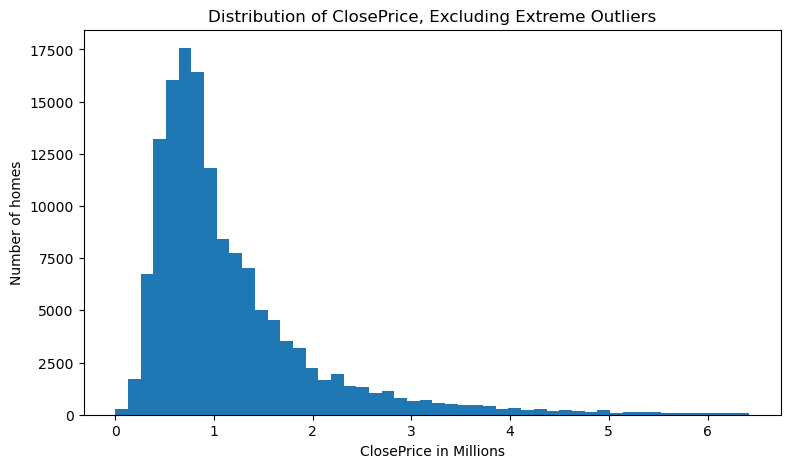

In [10]:
df_price = residential_df.copy()

df_price['ClosePrice'] = pd.to_numeric(df_price['ClosePrice'], errors='coerce')

df_price = df_price[
    (df_price['ClosePrice'].notna()) &
    (df_price['ClosePrice'] > 0) &
    (df_price['ClosePrice'] <= df_price['ClosePrice'].quantile(0.99))
]


plt.figure(figsize=(9, 5))
plt.hist(df_price['ClosePrice'] / 1_000_000, bins=50)

plt.title('Distribution of ClosePrice, Excluding Extreme Outliers')
plt.xlabel('ClosePrice in Millions')
plt.ylabel('Number of homes')

plt.show()

The ClosePrice distribution is right-skewed, meaning most homes sold in the lower-to-middle price range, while a smaller number of high-priced homes create a long tail on the right.

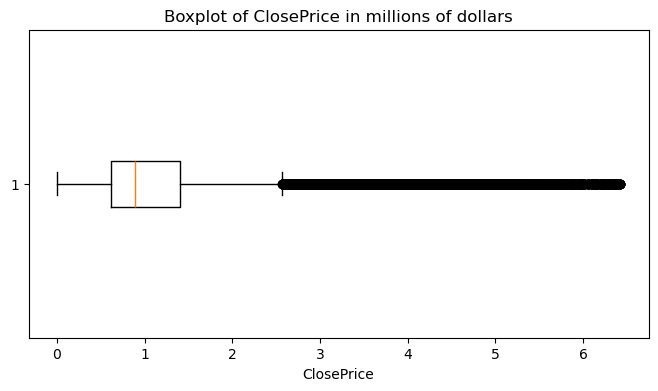

In [11]:
col = "ClosePrice"  # Replace with the column you want to plot
plt.figure(figsize=(8, 4))
plt.boxplot(df_price[col].dropna() / 1_000_000, vert=False)
plt.title(f'Boxplot of {col} in millions of dollars')
plt.xlabel(col)
plt.show()

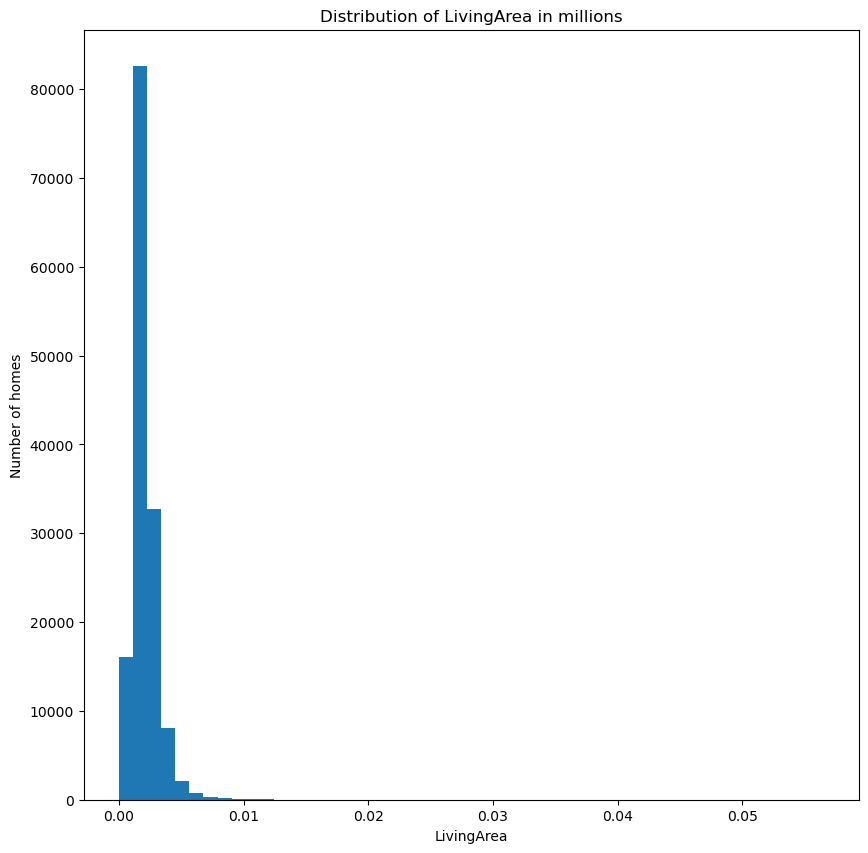

In [12]:
#'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'LotSizeArea', 'LotSizeAcres', 'MainLevelBedrooms' ]

import matplotlib.pyplot as plt
import numpy as np
col = 'LivingArea'  # Replace with the column you want to plot

plt.figure(figsize=(10, 10))
plt.hist(residential_df[col] / 1_000_000, bins=50)
plt.title(f'Distribution of {col} in millions')
plt.xlabel(col)
plt.ylabel('Number of homes')
plt.show()

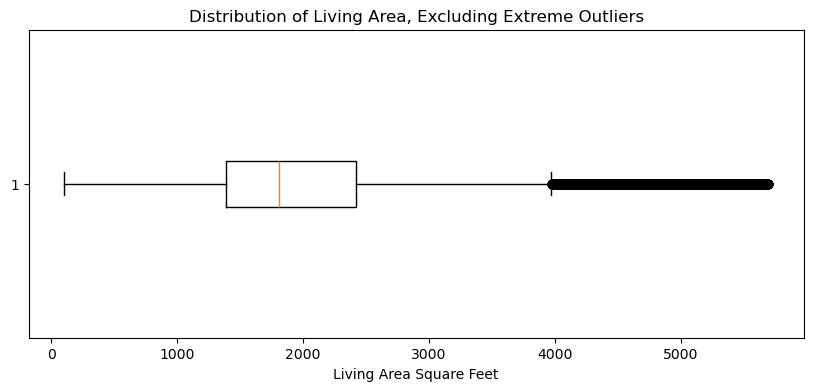

In [13]:
#'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'LotSizeArea', 'LotSizeAcres', 'MainLevelBedrooms' ]

import matplotlib.pyplot as plt
import pandas as pd

col = 'LivingArea'

living_area = pd.to_numeric(residential_df[col], errors='coerce')

living_area = living_area.dropna()
living_area = living_area[living_area > 0]

# Remove top 1% extreme outliers
living_area_clean = living_area[living_area <= living_area.quantile(0.99)]

plt.figure(figsize=(10, 4))
plt.boxplot(living_area_clean, vert=False)

plt.title('Distribution of Living Area, Excluding Extreme Outliers')
plt.xlabel('Living Area Square Feet')
plt.show()


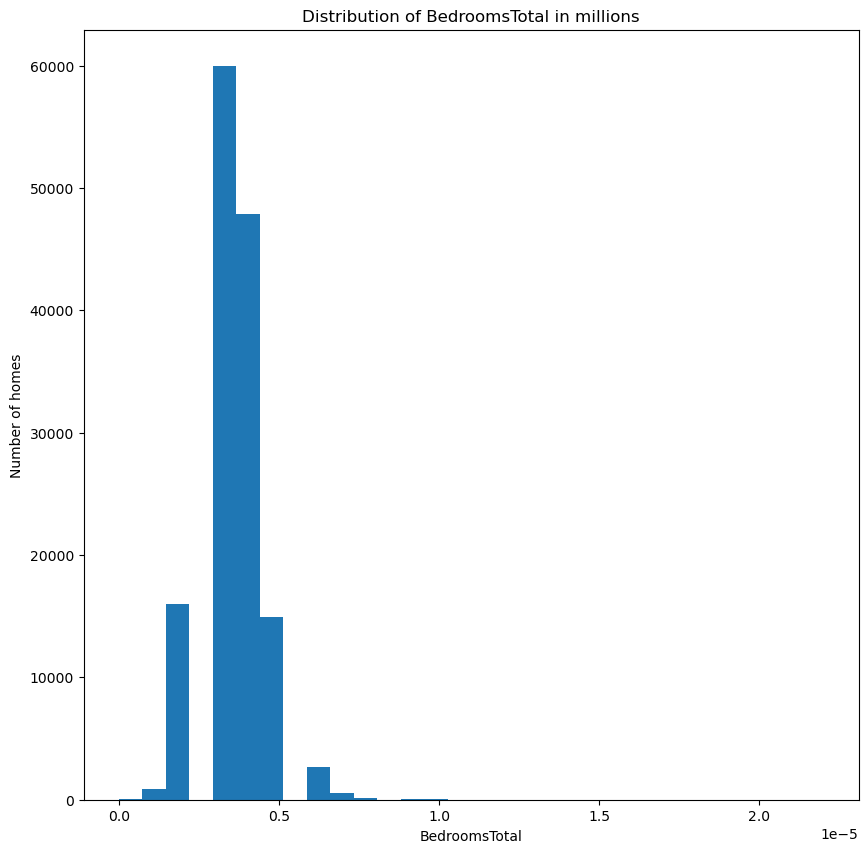

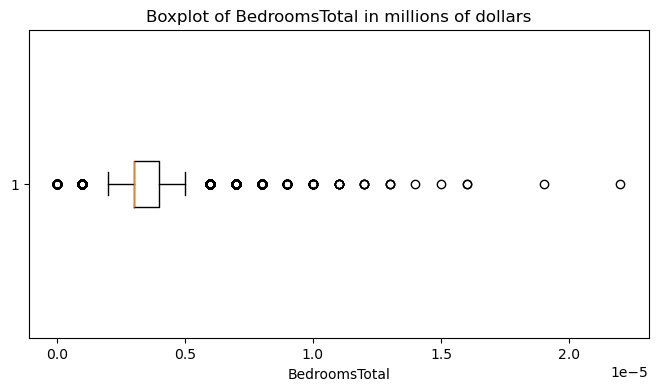

In [14]:
# 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'LotSizeArea', 'LotSizeAcres', 'MainLevelBedrooms' ]

import matplotlib.pyplot as plt
import numpy as np
col = 'BedroomsTotal'  # Replace with the column you want to plot

plt.figure(figsize=(10, 10))
plt.hist(residential_df[col] / 1_000_000, bins=30)
plt.title(f'Distribution of {col} in millions')
plt.xlabel(col)
plt.ylabel('Number of homes')
plt.show()


plt.figure(figsize=(8, 4))
plt.boxplot(residential_df[col].dropna() / 1_000_000, vert=False)
plt.title(f'Boxplot of {col} in millions of dollars')
plt.xlabel(col)
plt.show()

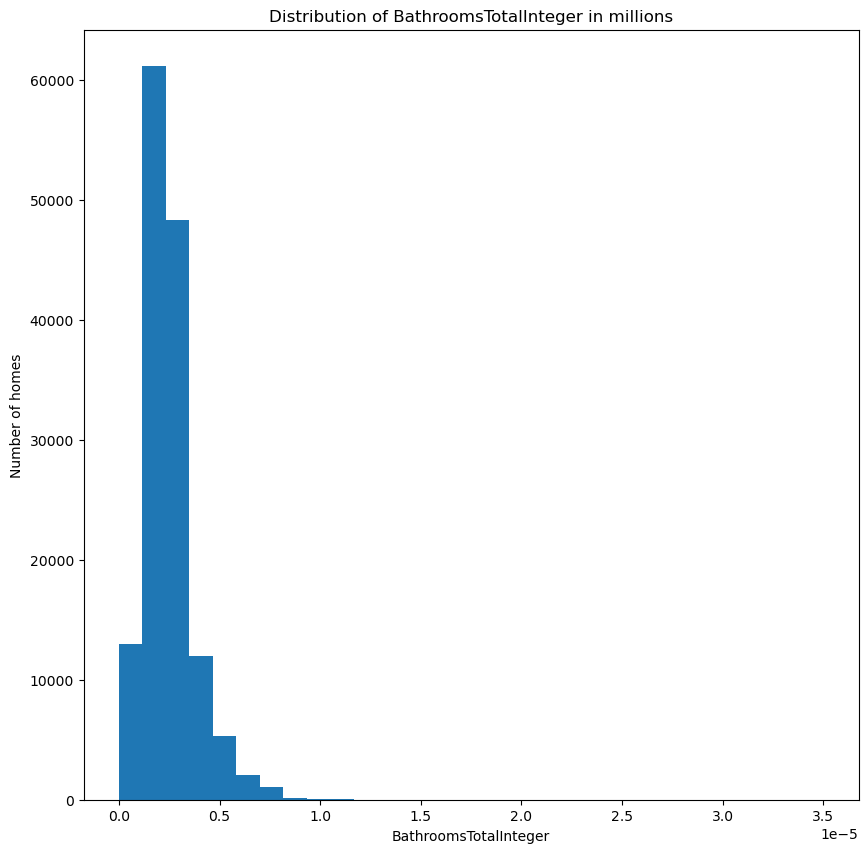

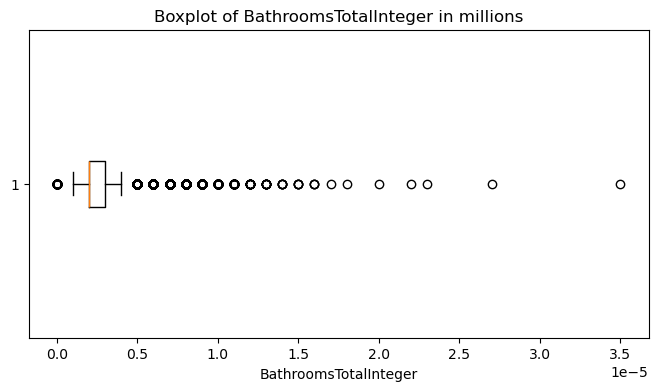

In [15]:
#  'BathroomsTotalInteger', 'LotSizeSquareFeet', 'LotSizeArea', 'LotSizeAcres', 'MainLevelBedrooms' ]

import matplotlib.pyplot as plt
import numpy as np
col = 'BathroomsTotalInteger'  # Replace with the column you want to plot

plt.figure(figsize=(10, 10))
plt.hist(residential_df[col] / 1_000_000, bins=30)
plt.title(f'Distribution of {col} in millions')
plt.xlabel(col)
plt.ylabel('Number of homes')
plt.show()


plt.figure(figsize=(8, 4))
plt.boxplot(residential_df[col].dropna() / 1_000_000, vert=False)
plt.title(f'Boxplot of {col} in millions')
plt.xlabel(col)
plt.show()

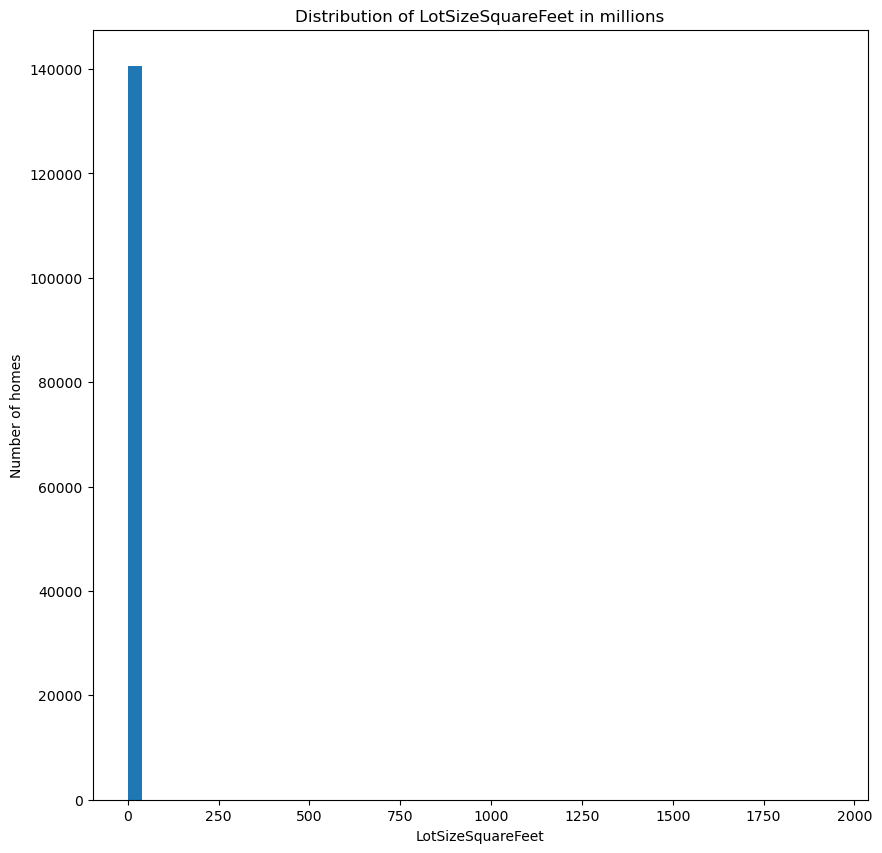

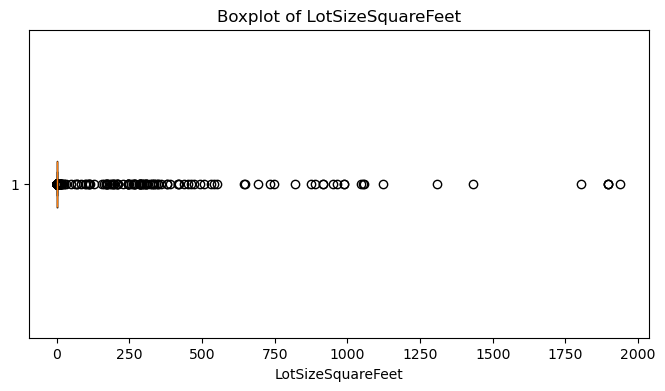

In [16]:
# 'LotSizeSquareFeet', 'LotSizeArea', 'LotSizeAcres', 'MainLevelBedrooms' ]

import matplotlib.pyplot as plt
import numpy as np
col = 'LotSizeSquareFeet'  # Replace with the column you want to plot

plt.figure(figsize=(10, 10))
plt.hist(residential_df[col] / 1_000_000, bins=50)
plt.title(f'Distribution of {col} in millions')
plt.xlabel(col)
plt.ylabel('Number of homes')
plt.show()


plt.figure(figsize=(8, 4))
plt.boxplot(residential_df[col].dropna() / 1_000_000, vert=False)
plt.title(f'Boxplot of {col}')
plt.xlabel(col)
plt.show()

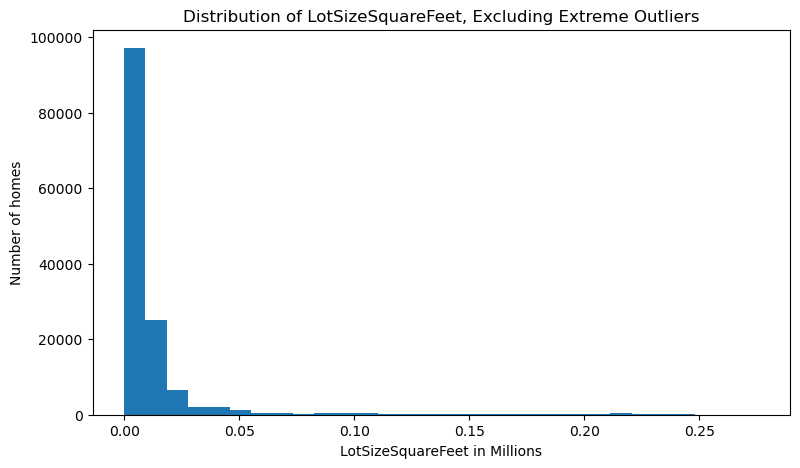

In [17]:
df_lot = residential_df.copy()

df_lot['LotSizeSquareFeet'] = pd.to_numeric(df_lot['LotSizeSquareFeet'], errors='coerce')

df_lot = df_lot[
    (df_lot['LotSizeSquareFeet'].notna()) &
    (df_lot['LotSizeSquareFeet'] > 0) &
    (df_lot['LotSizeSquareFeet'] <= df_lot['LotSizeSquareFeet'].quantile(0.99))
]


plt.figure(figsize=(9, 5))
plt.hist(df_lot['LotSizeSquareFeet'] / 1_000_000, bins=30)

plt.title('Distribution of LotSizeSquareFeet, Excluding Extreme Outliers')
plt.xlabel('LotSizeSquareFeet in Millions')
plt.ylabel('Number of homes')

plt.show()

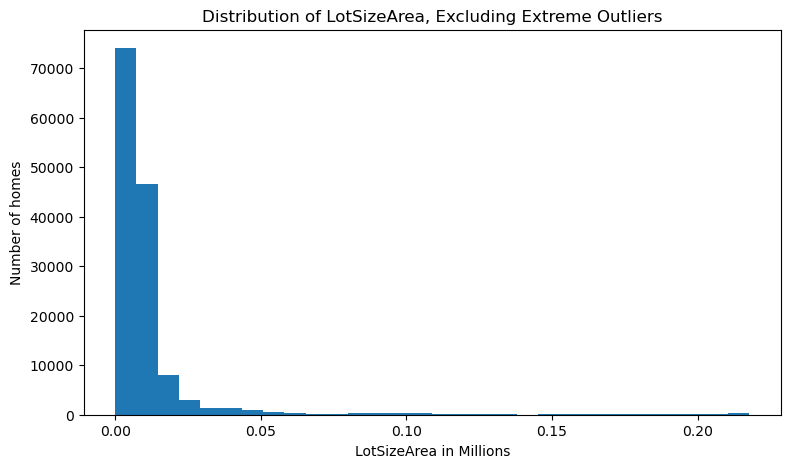

In [18]:
df_lot = residential_df.copy()

df_lot['LotSizeArea'] = pd.to_numeric(df_lot['LotSizeArea'], errors='coerce')

df_lot = df_lot[
    (df_lot['LotSizeArea'].notna()) &
    (df_lot['LotSizeArea'] > 0) &
    (df_lot['LotSizeArea'] <= df_lot['LotSizeArea'].quantile(0.99))
]


plt.figure(figsize=(9, 5))
plt.hist(df_lot['LotSizeArea'] / 1_000_000, bins=30)

plt.title('Distribution of LotSizeArea, Excluding Extreme Outliers')
plt.xlabel('LotSizeArea in Millions')
plt.ylabel('Number of homes')

plt.show()

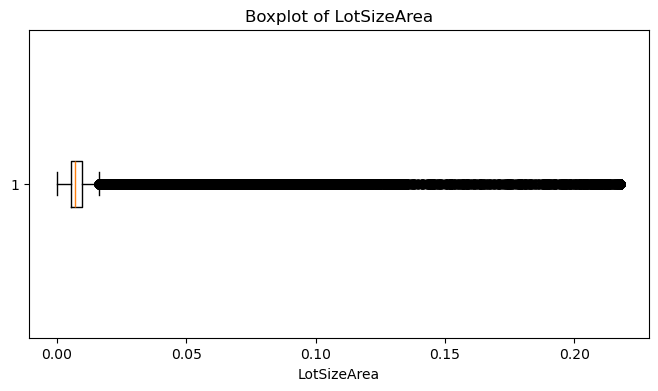

In [19]:
col = 'LotSizeArea'  # Replace with the column you want to plot
plt.figure(figsize=(8, 4))
plt.boxplot(df_lot[col].dropna() / 1_000_000, vert=False)
plt.title(f'Boxplot of {col}')
plt.xlabel(col)
plt.show()

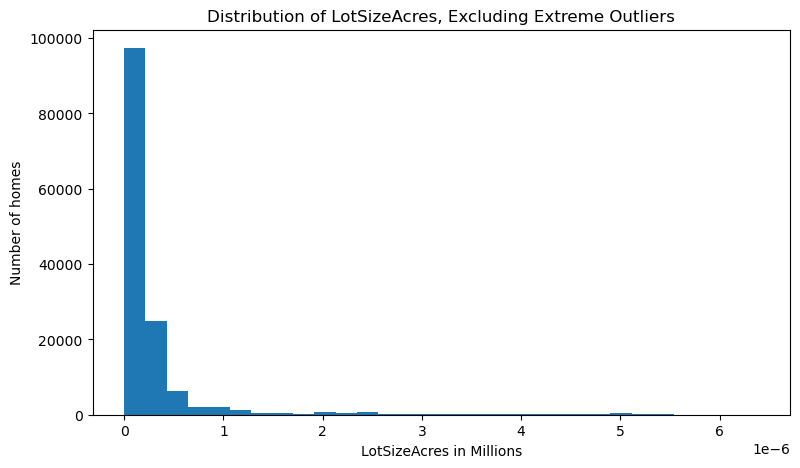

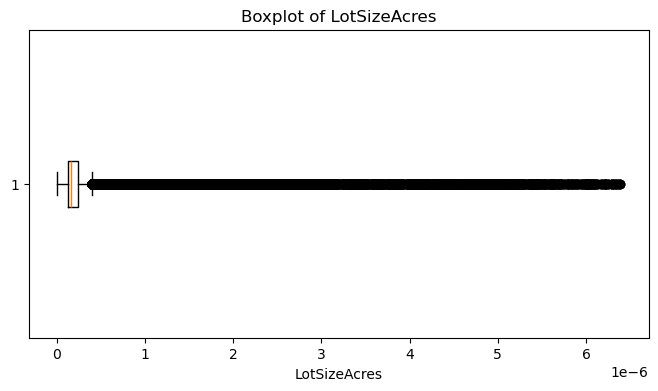

In [20]:
df_lot = residential_df.copy()

df_lot['LotSizeAcres'] = pd.to_numeric(df_lot['LotSizeAcres'], errors='coerce')

df_lot = df_lot[
    (df_lot['LotSizeAcres'].notna()) &
    (df_lot['LotSizeAcres'] > 0) &
    (df_lot['LotSizeAcres'] <= df_lot['LotSizeAcres'].quantile(0.99))
]


plt.figure(figsize=(9, 5))
plt.hist(df_lot['LotSizeAcres'] / 1_000_000, bins=30)

plt.title('Distribution of LotSizeAcres, Excluding Extreme Outliers')
plt.xlabel('LotSizeAcres in Millions')
plt.ylabel('Number of homes')

plt.show()

col = 'LotSizeAcres'  # Replace with the column you want to plot
plt.figure(figsize=(8, 4))
plt.boxplot(df_lot[col].dropna() / 1_000_000, vert=False)
plt.title(f'Boxplot of {col}')
plt.xlabel(col)
plt.show()

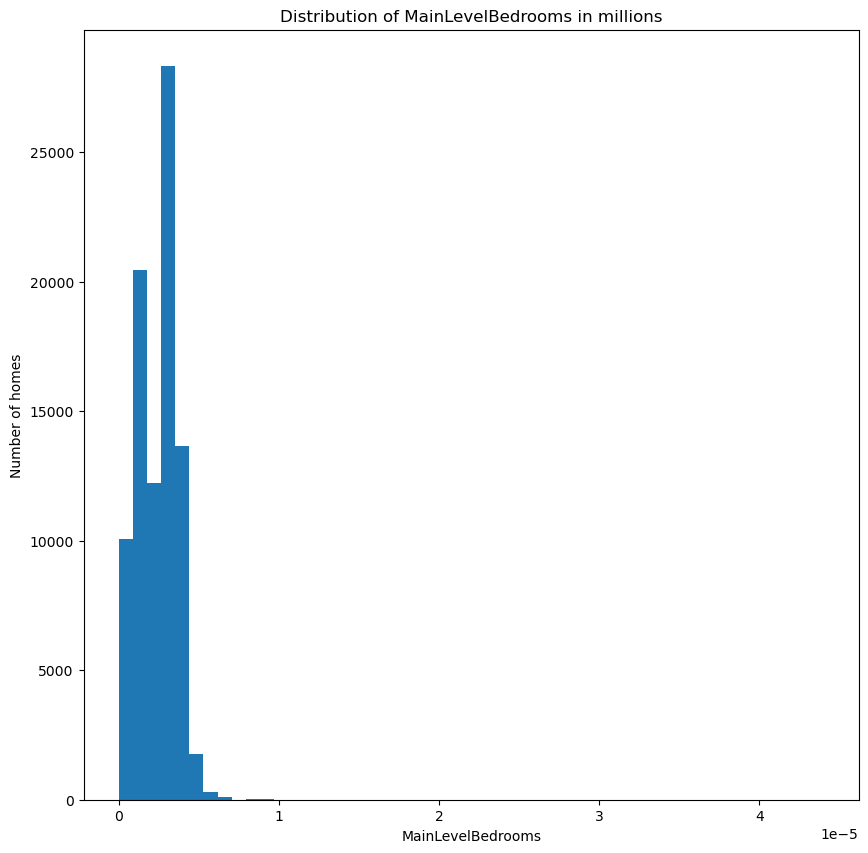

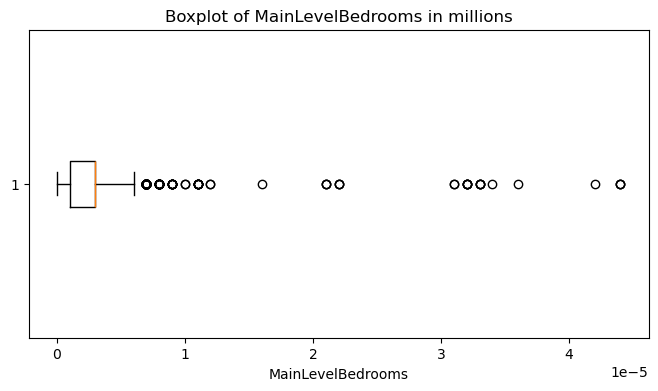

In [21]:
#  'MainLevelBedrooms' ]

import matplotlib.pyplot as plt
import numpy as np
col = 'MainLevelBedrooms'  # Replace with the column you want to plot

plt.figure(figsize=(10, 10))
plt.hist(residential_df[col] / 1_000_000, bins=50)
plt.title(f'Distribution of {col} in millions')
plt.xlabel(col)
plt.ylabel('Number of homes')
plt.show()


plt.figure(figsize=(8, 4))
plt.boxplot(residential_df[col].dropna() / 1_000_000, vert=False)
plt.title(f'Boxplot of {col} in millions')
plt.xlabel(col)
plt.show()

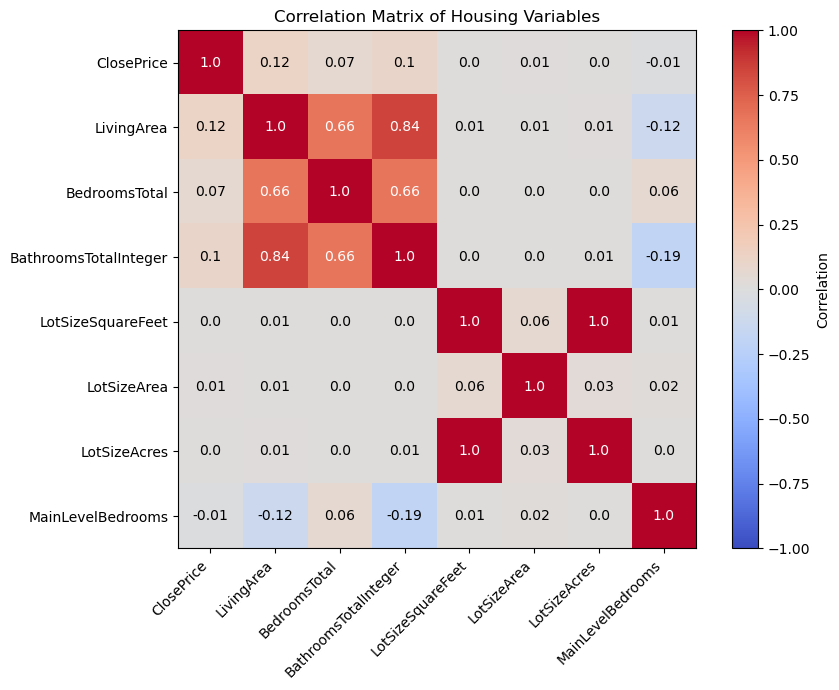

In [22]:
corr = residential_df[cols].corr()

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 7))

# Use a diverging color map centered around 0
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr.columns)), 
    corr.columns, 
    rotation=45, 
    ha='right'
)

plt.yticks(
    range(len(corr.columns)), 
    corr.columns
)

# Add correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        
        # Make text color easier to read
        text_color = 'white' if abs(value) > 0.5 else 'black'
        
        plt.text(
            j, i, 
            round(value, 2), 
            ha='center', 
            va='center',
            color=text_color
        )

plt.title('Correlation Matrix of Housing Variables')
plt.tight_layout()
plt.show()

The correlation matrix shows that property characteristics are strongly related to each other. LivingArea has a strong positive correlation with BathroomsTotalInteger at 0.84 and a moderate-to-strong correlation with BedroomsTotal at 0.66, suggesting that larger homes generally have more bedrooms and bathrooms. However, ClosePrice has weak correlations with the selected physical features, such as LivingArea, BedroomsTotal, and BathroomsTotalInteger. This suggests that price may be influenced by additional factors not shown in the matrix, such as location, neighborhood, market timing, or property condition. LotSizeSquareFeet and LotSizeAcres have a correlation of 1.00 because they measure the same concept in different units, so only one should be used in later analysis.

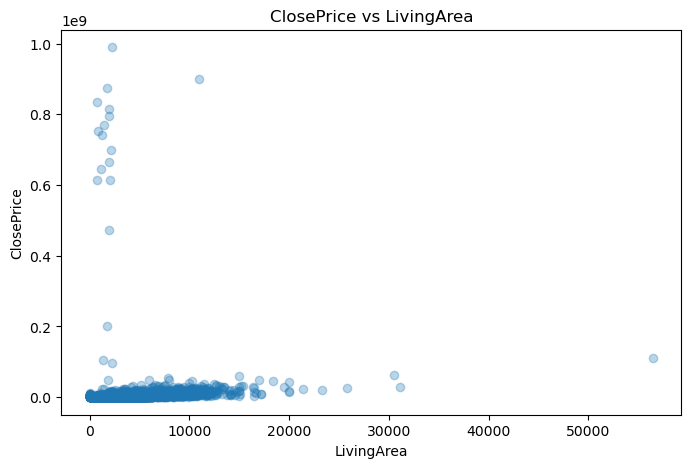

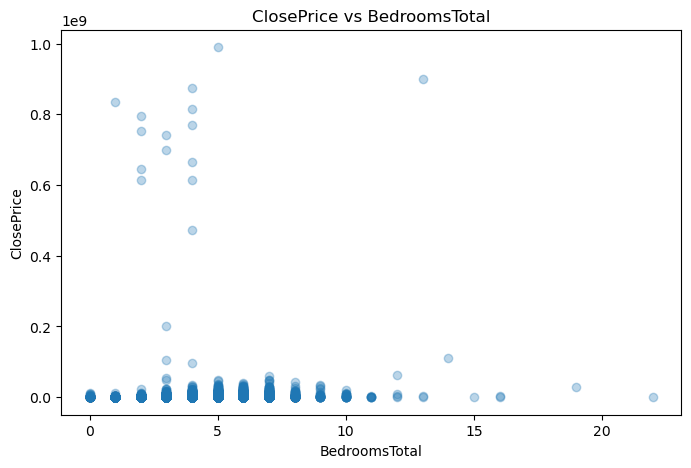

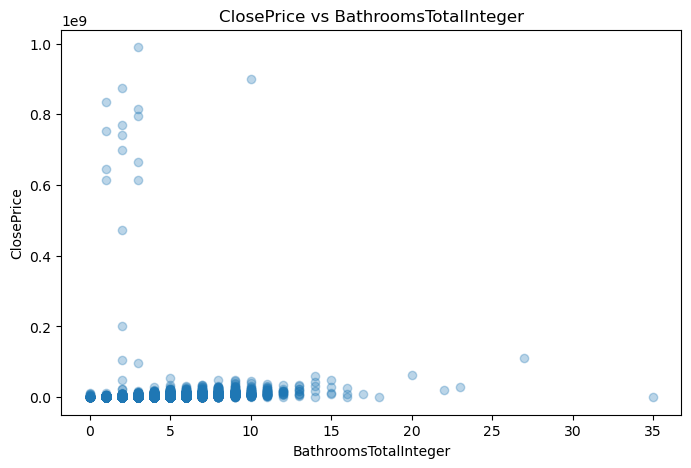

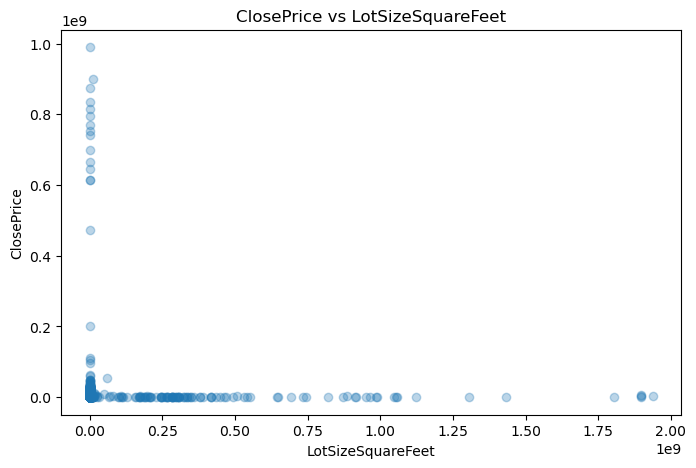

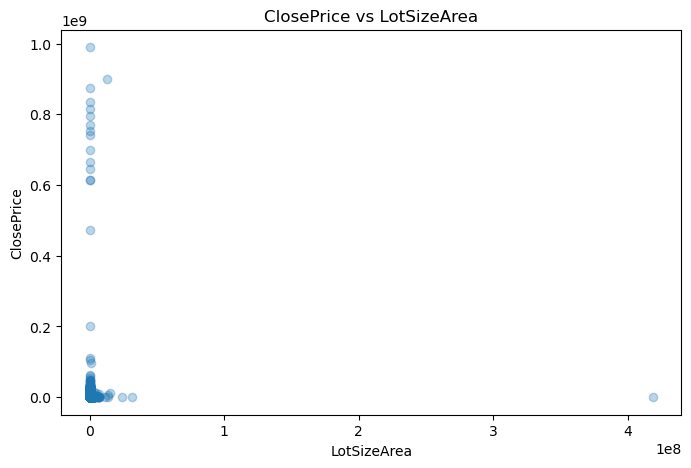

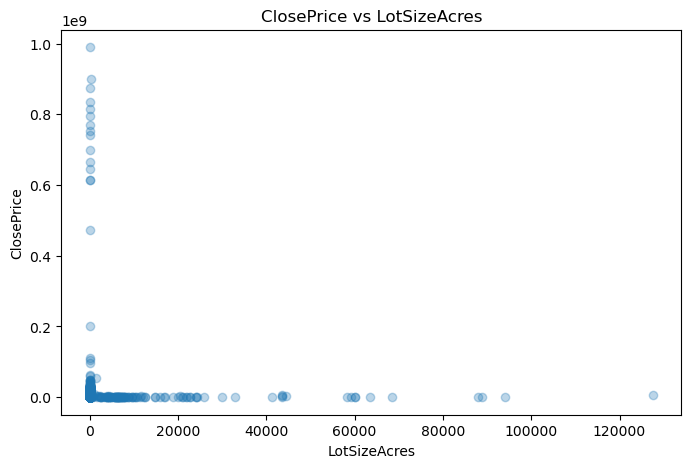

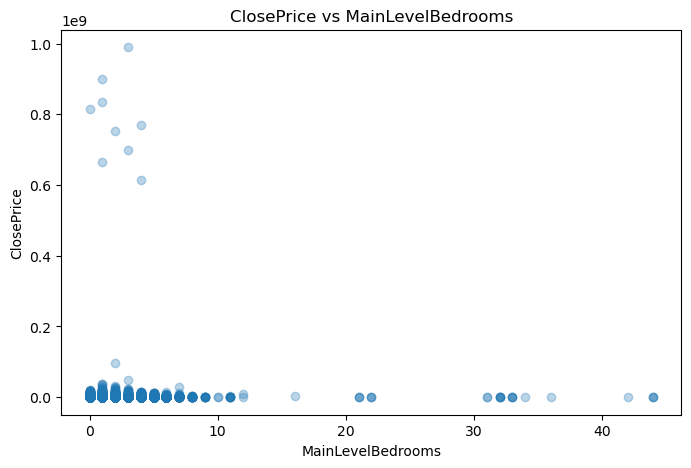

In [23]:
predictors = [col for col in cols if col != 'ClosePrice']

for col in predictors:
    plt.figure(figsize=(8, 5))
    plt.scatter(residential_df[col], residential_df['ClosePrice'], alpha=0.3)
    plt.title(f'ClosePrice vs {col}')
    plt.xlabel(col)
    plt.ylabel('ClosePrice')
    plt.show()

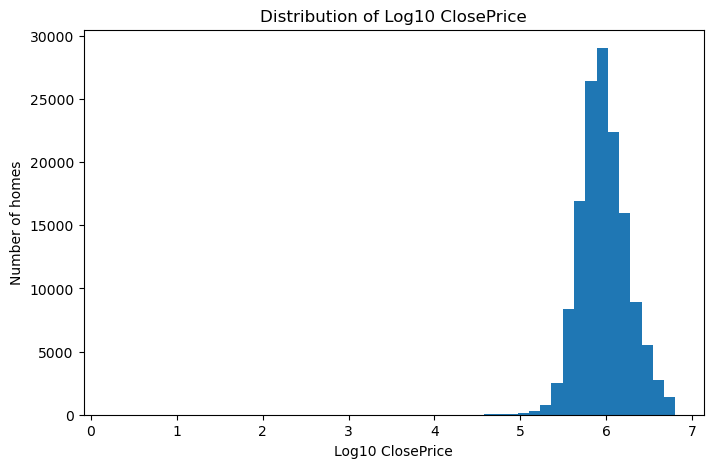

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(np.log10(df_price['ClosePrice'].dropna()), bins=50)
plt.title('Distribution of Log10 ClosePrice')
plt.xlabel('Log10 ClosePrice')
plt.ylabel('Number of homes')
plt.show()

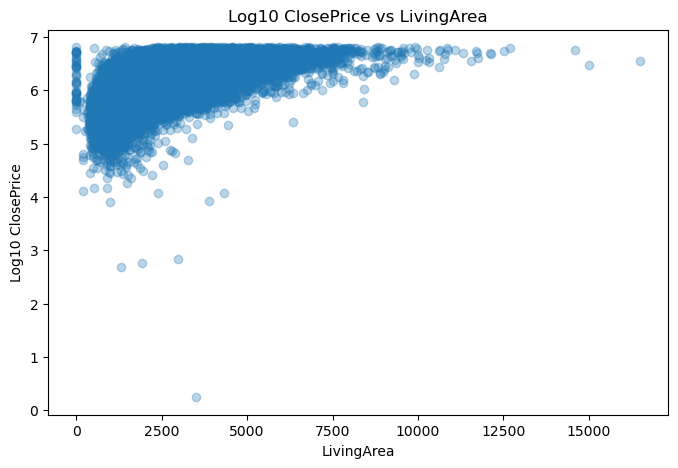

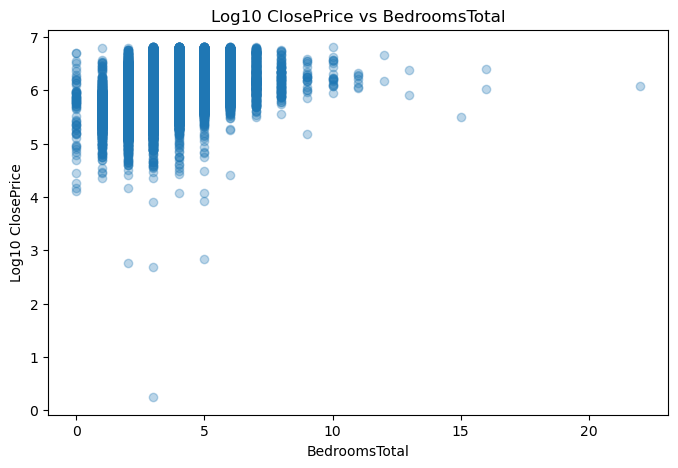

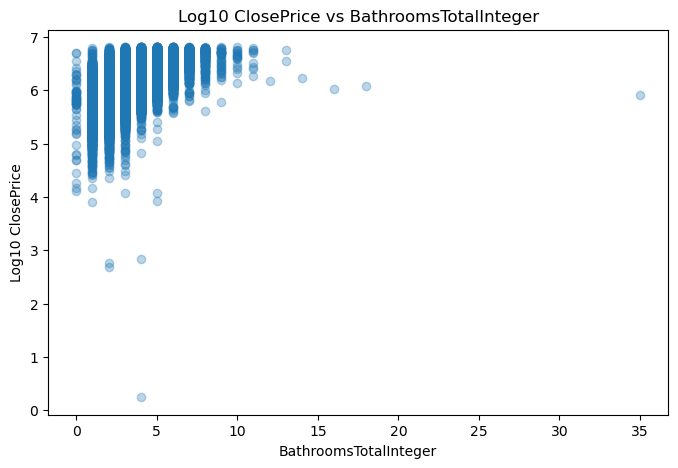

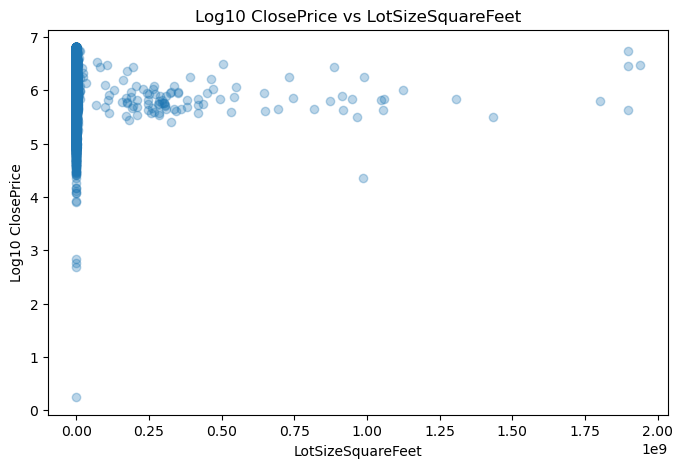

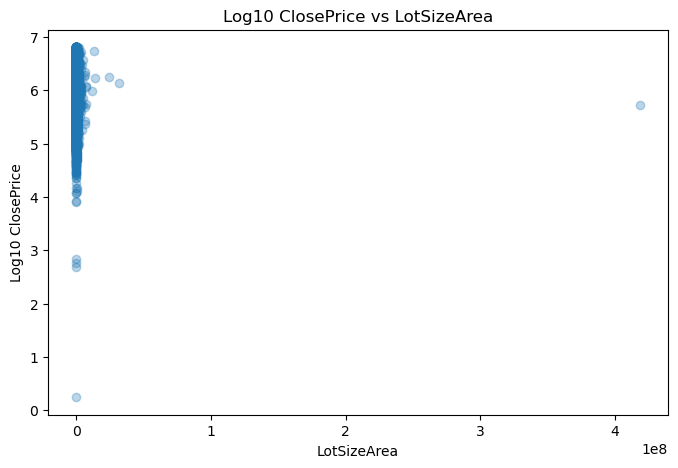

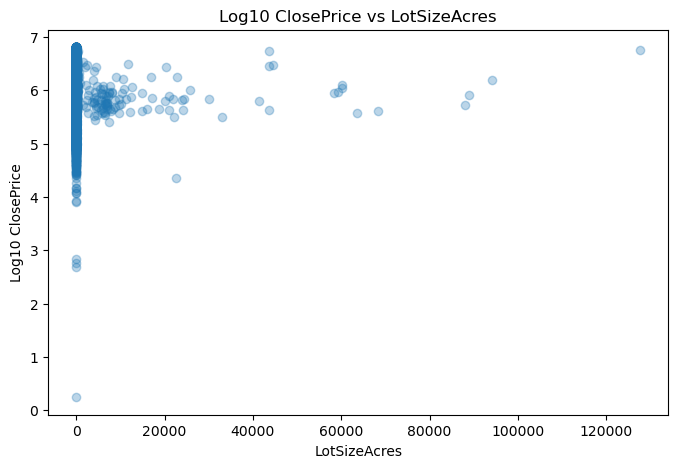

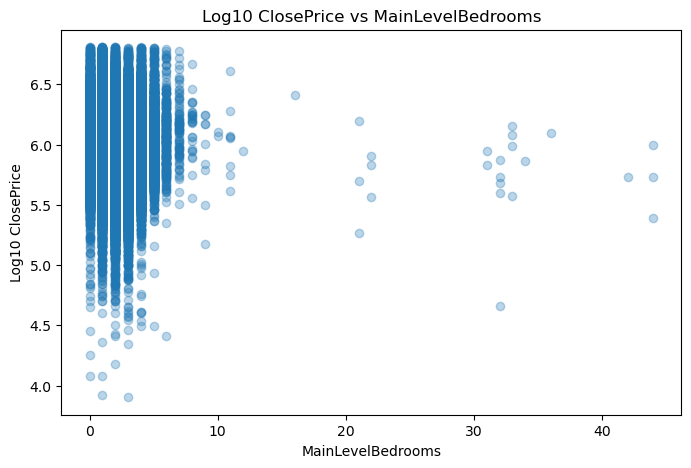

In [25]:
for col in predictors:
    plt.figure(figsize=(8, 5))
    plt.scatter(df_price[col], np.log10(df_price['ClosePrice']), alpha=0.3)
    plt.title(f'Log10 ClosePrice vs {col}')
    plt.xlabel(col)
    plt.ylabel('Log10 ClosePrice')
    plt.show()